# Comparing Classifiers: Predicting Bank Term-Deposit Subscriptions

**Practical Application Assignment 3**

This notebook compares four classification models — **K-Nearest Neighbors, Logistic Regression,
Decision Trees, and Support Vector Machines** — on a real telemarketing dataset from a
Portuguese retail bank.

**Data source:** UCI Machine Learning Repository, *Bank Marketing* dataset
(Moro, Cortez & Rita, 2014). File used: bank-additional-full.csv (41,188 calls, 20 inputs).


---
## 1. Business Understanding

### The situation
A Portuguese bank sells term deposits (a savings product where money is locked in for a
fixed period at a fixed interest rate) by calling customers on the phone. Each call costs the
bank money: an agent's time, phone costs, and the risk of annoying a customer who is not
interested.

In this dataset, only about 11 out of every 100 calls end in a sale. So roughly 89% of the
call-centre effort produces nothing.

### The business question
Can we predict, before we dial, which customers are likely to say yes, so the call
centre can spend its limited hours on the most promising people?

### How this turns into a data problem
- **Task type:** supervised binary classification.
- **Target variable:** y — did the customer subscribe to the term deposit? (yes / no)
- **Inputs:** customer details (age, job, education), campaign details (how many times we
  called, what happened last time…), and the economic climate at the time of the call.
- **What success looks like:** a model that ranks customers by their chance of subscribing,
  so the bank can call the top of the list first.

### One critical rule we set up front
The dataset contains a column called duration — how many seconds the call lasted. It is
extremely predictive (long calls almost always mean a sale), **but we only know it after the
call is over**. Using it would build a model we could never use in real life. The dataset
authors say the same. We delete duration before modeling.


---
## 2. Setup and Loading the Data

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, f1_score,
                             recall_score, precision_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

import time, warnings
warnings.filterwarnings('ignore')   # keep the notebook output clean

# Display settings so tables and plots are easy to read
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pio.renderers.default = 'notebook'  # makes plotly charts render inside the notebook

RANDOM_STATE = 42   # fixed seed so every run gives the same result
print('Libraries loaded.')

Libraries loaded.


In [2]:
# The file uses semicolons as separators, not commas
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 41,188   Columns: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Quick structural check: data types and missing values
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'unique_values': df.nunique()
})
info

,dtype,missing,unique_values
age,int64,0,78
job,object,0,12
marital,object,0,4
education,object,0,8
default,object,0,3
housing,object,0,3
loan,object,0,3
contact,object,0,2
month,object,0,10
day_of_week,object,0,5


41,188 rows and 21 columns, and **no missing values (`NaN`)**.
But that does not mean the data is clean, this dataset hides its missing values inside the
word "unknown", which we deal with next.

---
## 3. Data Cleaning

We handle four issues, one at a time:

1. Duplicate rows
2. `"unknown"` values hiding inside categorical columns
3. The `duration` leakage column
4. The `pdays` column, where the number `999` really means *"never contacted before"*

In [4]:
# --- Issue 1: duplicate rows ---
n_dupes = df.duplicated().sum()
print(f'Exact duplicate rows found: {n_dupes}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'Rows after removing duplicates: {df.shape[0]:,}')

Exact duplicate rows found: 12
Rows after removing duplicates: 41,176


In [5]:
# --- Issue 2: how much "unknown" is there in each text column? ---
text_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype) == 'str']
print (f'Text columns : {text_cols}')

unknown_share = (df[text_cols].eq('unknown').mean() * 100).round(2)
unknown_share = unknown_share[unknown_share > 0].sort_values(ascending=False)

print('Percentage of rows marked "unknown":')
print(unknown_share.to_string())

Text columns : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Percentage of rows marked "unknown":
default      20.88
education     4.20
housing       2.40
loan          2.40
job           0.80
marital       0.19


**Decision:** we keep "unknown" as its own category instead of deleting those rows.

Reasons in plain English:
- Dropping them would throw away about a quarter of the data (default alone is 21% unknown).
- "Customer refused to tell us" can itself be a useful signal, so it is worth keeping.

The only column where "unknown" is very rare is marital (0.19%), and keeping it there costs
us nothing.

In [6]:
# --- Issue 3: remove the leakage column ---
# column duration is only known AFTER the call ends, so a real prediction cannot use it.
df = df.drop(columns='duration')
print('Dropped column duration. Columns left:', df.shape[1])

Dropped column duration. Columns left: 20


In [7]:
# --- Issue 4: pdays uses 999 to mean "this client was never contacted before" ---
print('How often pdays = 999:', f'{(df["pdays"] == 999).mean():.1%}')

# Turn that hidden code into an honest yes/no flag, then drop the confusing number column.
df['contacted_before'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns='pdays')

print(df['contacted_before'].value_counts().rename({0: 'never contacted', 1: 'contacted before'}).to_string())

How often pdays = 999: 96.3%
contacted_before
never contacted     39661
contacted before     1515


In [8]:
# --- Tidy-up: simplify the education levels and make the target numeric ---

# basic.4y / basic.6y / basic.9y all mean "basic schooling" -> group them into one label
df['education'] = df['education'].replace({'basic.4y': 'basic', 'basic.6y': 'basic', 'basic.9y': 'basic'})

# Convert the target from yes/no text to 1/0 so the models can use it
df['subscribed'] = (df['y'] == 'yes').astype(int)
df = df.drop(columns='y')

print('Education levels now:', sorted(df['education'].unique()))
print('\nTarget balance:')
print(df['subscribed'].value_counts(normalize=True).rename({0: 'no', 1: 'yes'}).mul(100).round(2).to_string())

Education levels now: ['basic', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']

Target balance:
subscribed
no     88.73
yes    11.27


**Cleaning summary:** 12 duplicates removed, duration dropped (leakage), pdays replaced by
a clear contacted_before flag, education levels simplified, and the target renamed to
subscribed (1 = signed up, 0 = did not).

**The key number to remember: only 11.3% of calls succeed.** This class imbalance drives every
modeling decision later on.

---
## 4. Exploratory Data Analysis (Descriptive Statistics)

We look at the target first, then the numeric columns, then the categorical columns.

In [9]:
# Split the column names into numeric and categorical - we reuse these lists everywhere
target = 'subscribed'
numeric_cols = df.select_dtypes(include=np.number).columns.drop(target).tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target]]

print('Numeric columns     :', numeric_cols)
print('Categorical columns :', categorical_cols)

Numeric columns     : ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'contacted_before']
Categorical columns : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [11]:
# Descriptive statistics for the numeric columns
df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
campaign,41176.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
previous,41176.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41176.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41176.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41176.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41176.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41176.0,5167.03,72.25,4963.60,5099.10,5191.00,5228.10,5228.10
contacted_before,41176.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00


**Reading the table:**
1. The average customer is 40 years old, ranging from 17 to 98.
2. campaign (calls made in this campaign): the median is 2, but the maximum is 56 — a few
  customers were called relentlessly.
3. previous is 0 for most people: the large majority had never been contacted before.
4. The last five columns (emp.var.rate through nr.employed) are economic indicators.
  They describe the country, not the person: employment variation rate, consumer price index,
  consumer confidence, the Euribor interest rate, and the number of people employed.

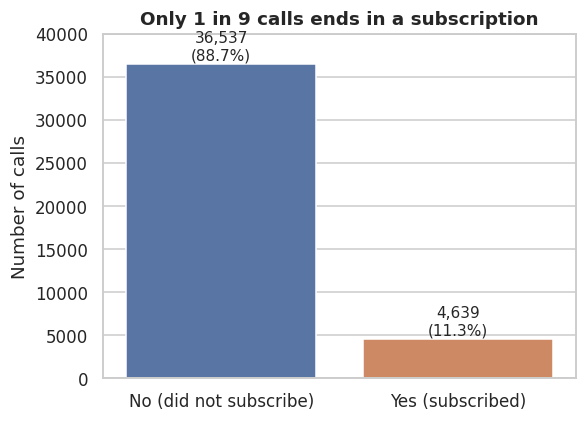

In [11]:
# How imbalanced is the target? A picture makes it obvious.
fig, ax = plt.subplots(figsize=(5.5, 4))
counts = df[target].value_counts().rename({0: 'No (did not subscribe)', 1: 'Yes (subscribed)'})
sns.barplot(x=counts.index, y=counts.values, ax=ax, hue=counts.index, legend=False)

for i, v in enumerate(counts.values):
  # write the % on top of each bar
  ax.text(i, v + 400, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)

ax.set_title('Only 1 in 9 calls ends in a subscription', fontsize=12, weight='bold')
ax.set_ylabel('Number of calls')
ax.set_xlabel('')
ax.set_ylim(0, 40000)
plt.tight_layout()
plt.show()

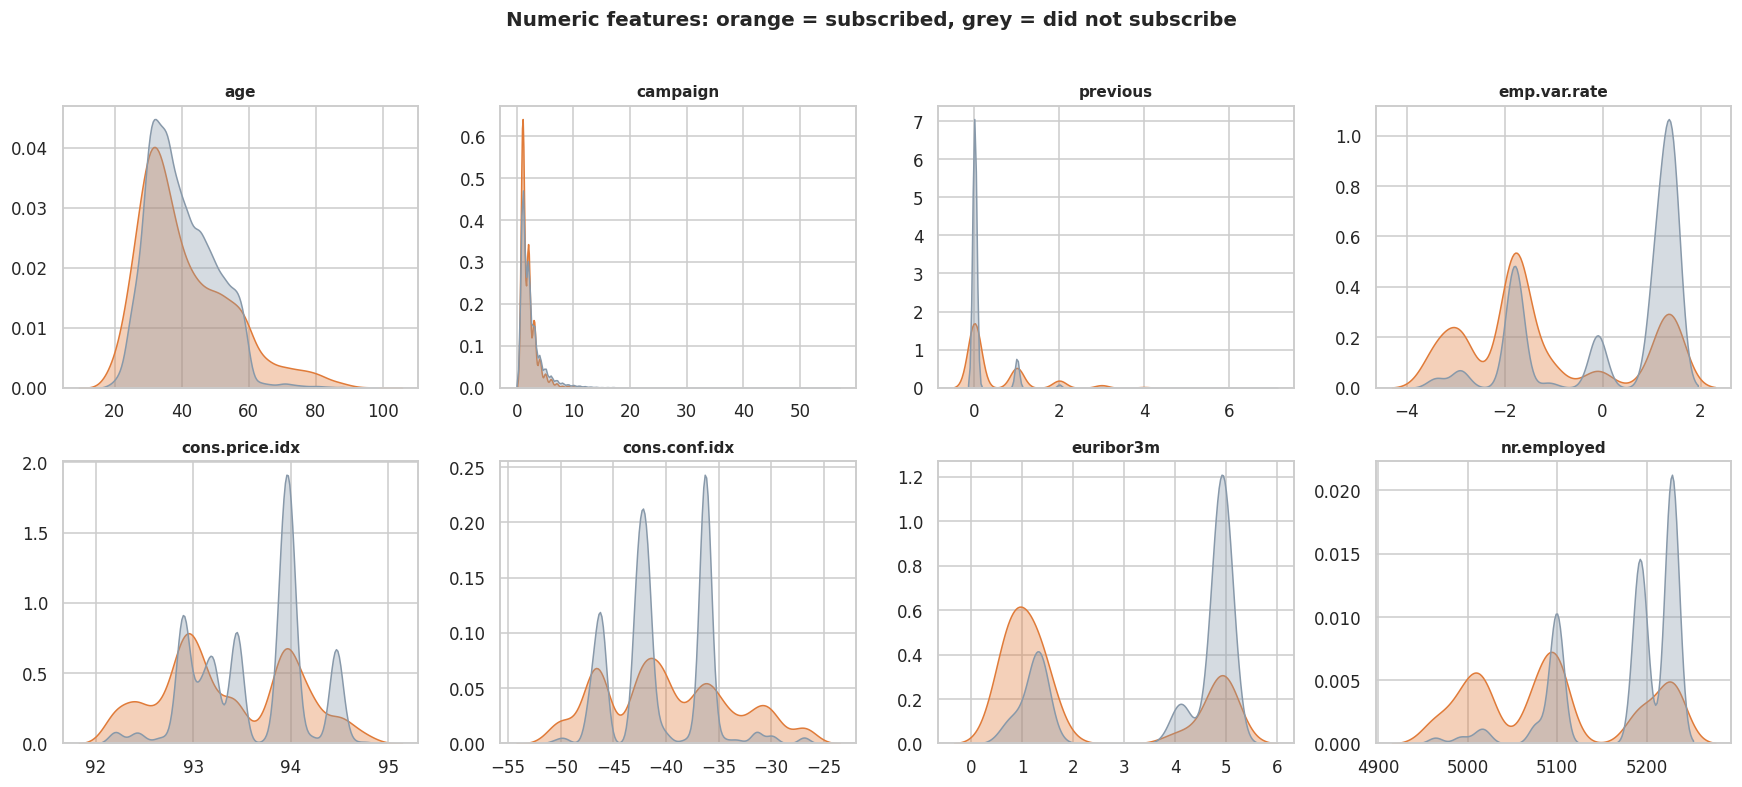

In [12]:
# Distribution of each numeric feature, split by whether the customer subscribed.
# `contacted_before` is a 0/1 flag, so a density curve would not make sense for it.
continuous_cols = [c for c in numeric_cols if c != 'contacted_before']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), continuous_cols):
    sns.kdeplot(data=df, x=col, hue=target, common_norm=False,
                fill=True, alpha=.35, ax=ax, palette=['#8899AA', '#E07B39'])
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    if ax.get_legend():
        ax.get_legend().remove()

fig.suptitle('Numeric features: orange = subscribed, grey = did not subscribe',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What stands out:** the economic indicators separate the two groups far more clearly than the
customer's personal details do. Subscriptions cluster where the **Euribor rate is low** and the
**number of employed people is low** — that is, during the weaker part of the economic cycle,
when a guaranteed-return deposit looks attractive. Age barely separates the groups at all.

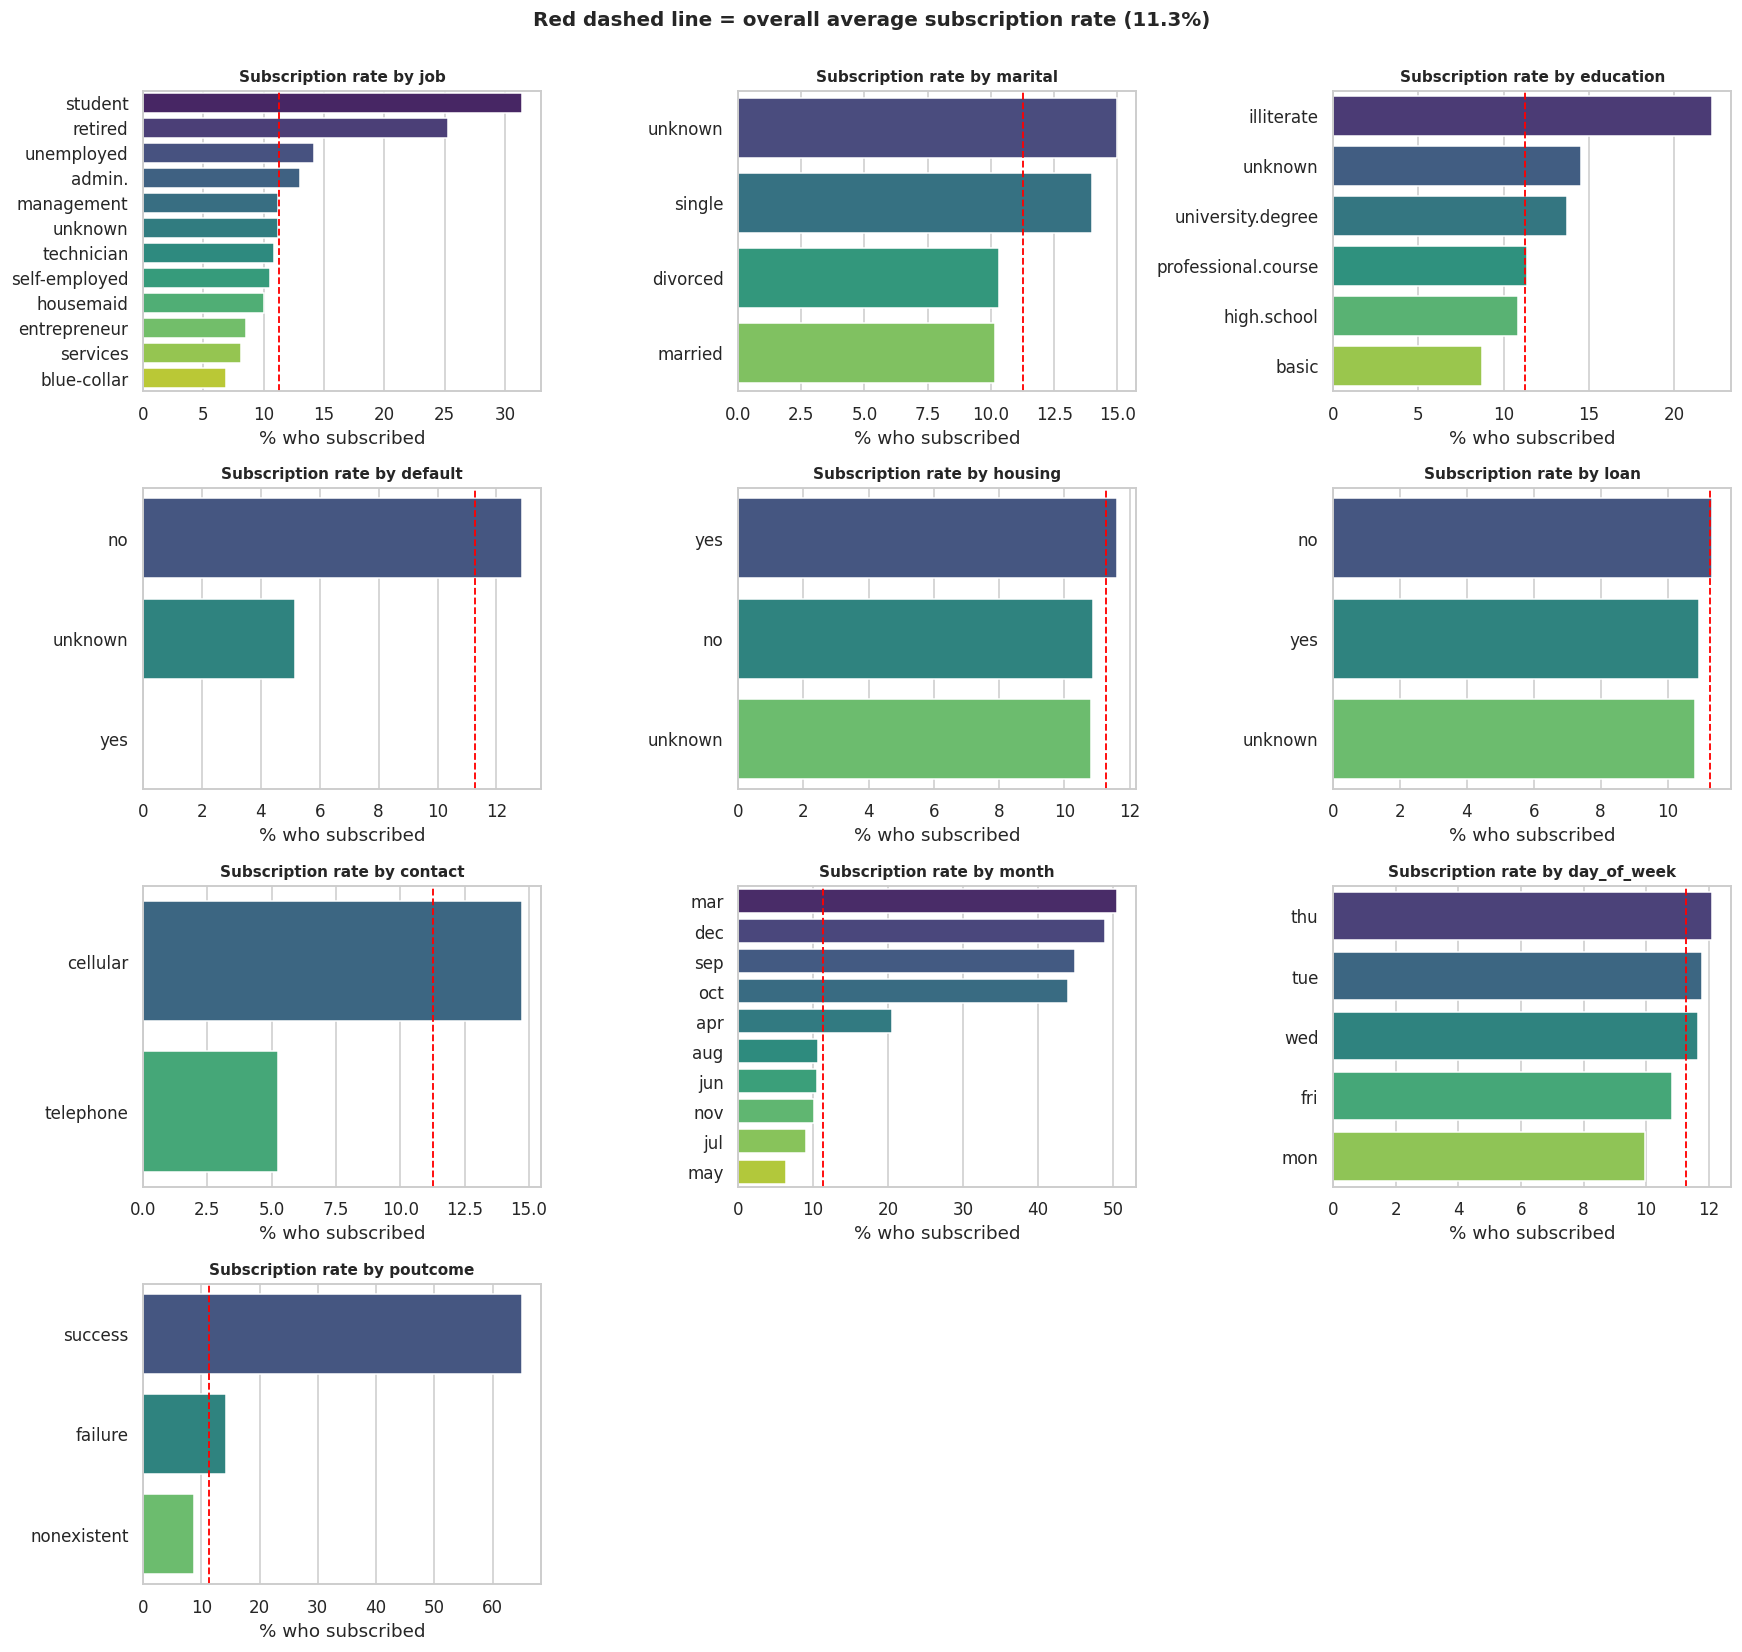

In [13]:
# Subscription rate for every level of every categorical feature.
# A rate is far more useful to the business than a raw count.
fig, axes = plt.subplots(4, 3, figsize=(16, 15))
flat_axes = axes.flatten()

for ax, col in zip(flat_axes, categorical_cols):
    rate = df.groupby(col)[target].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, hue=rate.index,
                palette='viridis', legend=False)
    ax.axvline(df[target].mean() * 100, color='red', ls='--', lw=1.2)  # overall average
    ax.set_title(f'Subscription rate by {col}', fontsize=10, weight='bold')
    ax.set_xlabel('% who subscribed')
    ax.set_ylabel('')

for ax in flat_axes[len(categorical_cols):]:   # hide any leftover empty panels
    ax.axis('off')

fig.suptitle('Red dashed line = overall average subscription rate (11.3%)',
             fontsize=13, weight='bold', y=1.0)
plt.tight_layout()
plt.show()

**The biggest wins visible here:**
- **poutcome = success**: customers who said yes to a previous campaign subscribe again
  about **65%** of the time — roughly six times the average.
- **contact = cellular**: mobile calls convert about three times better than landline calls.
- **Students and retired people** subscribe two to three times more often than average, while
  **blue-collar workers** are well below average.
- **Month** matters enormously: March, September, October and December convert very well; May,
  the busiest month by far, converts poorly.

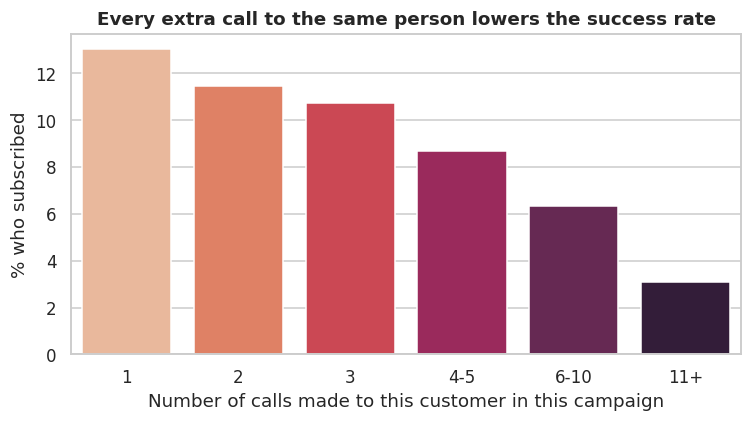

In [14]:
# Do repeated calls help? Check the success rate by number of attempts in this campaign.
attempts = df.copy()
attempts['attempt_group'] = pd.cut(attempts['campaign'], bins=[0, 1, 2, 3, 5, 10, 60],
                                   labels=['1', '2', '3', '4-5', '6-10', '11+'])
rate_by_attempt = attempts.groupby('attempt_group', observed=True)[target].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=rate_by_attempt.index, y=rate_by_attempt.values, ax=ax,
            hue=rate_by_attempt.index, palette='rocket_r', legend=False)
ax.set_title('Every extra call to the same person lowers the success rate',
             fontsize=12, weight='bold')
ax.set_xlabel('Number of calls made to this customer in this campaign')
ax.set_ylabel('% who subscribed')
plt.tight_layout()
plt.show()

**Clear downward trend:** the first call converts at **13%**, the fourth or fifth at **8.7%**,
and by the eleventh attempt the rate has fallen to **3.1%**. Persistence is not paying for
itself.

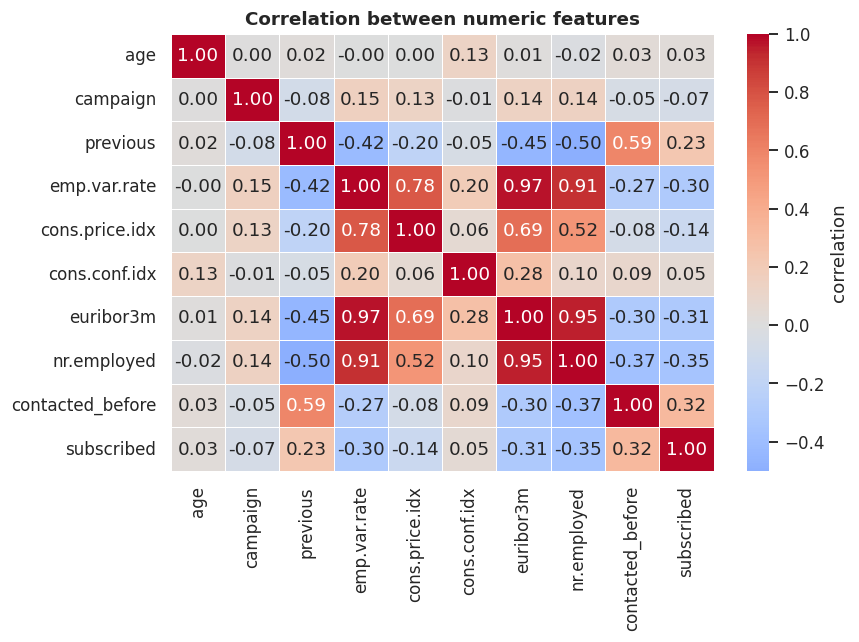

In [15]:
# Correlation between numeric features - useful for spotting redundant columns
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_cols + [target]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=.5, cbar_kws={'label': 'correlation'}, ax=ax)
ax.set_title('Correlation between numeric features', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

**Important caution for later:** the economic indicators are very strongly correlated with
each other (euribor3m and nr.employed correlate at 0.95, and both correlate strongly with
emp.var.rate).

---
## 5. Data Transformation and the Modeling Pipeline

Machine-learning models need numbers, not words, and several models need all features to be on a
comparable scale. We do both jobs inside a **scikit-learn Pipeline** so that the same steps
are applied automatically to training data, validation folds, and test data.

| Step | What it does | Why |
|---|---|---|
| **OneHotEncoder** | Turns each category into its own 0/1 column | Models cannot read text |
| **StandardScaler** | Rescales numbers to mean 0, spread 1 | KNN and SVM measure distance, so a column in thousands would drown one in single digits |

Doing this inside a pipeline avoids **data leakage**: the scaler learns its averages from the
training rows only, never from the test rows.

In [16]:
# Separate the inputs (X) from the thing we want to predict (y)
X = df.drop(columns=target)
y = df[target]

# Hold back 20% of the data as a final exam the models never see during training.
# `stratify=y` keeps the same 11.3% yes-rate in both halves.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f'Training rows: {len(X_train):,}   Test rows: {len(X_test):,}')
print(f'Yes-rate in train: {y_train.mean():.3%}   in test: {y_test.mean():.3%}')

Training rows: 32,940   Test rows: 8,236
Yes-rate in train: 11.266%   in test: 11.268%


In [17]:
# Build the preprocessing recipe once, then reuse it for every model
preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
    ('numeric', StandardScaler(), numeric_cols)
])

# Check how many columns the models will actually see after encoding
n_features = preprocessor.fit_transform(X_train).shape[1]
print(f'Original columns: {X_train.shape[1]}  ->  after one-hot encoding: {n_features}')

Original columns: 19  ->  after one-hot encoding: 50


---
## 6. A Baseline Model and Choosing the Evaluation Metric

### The baseline
Before building anything clever, we need a score to beat. The simplest possible "model" predicts
**"no" for everyone**.

In [18]:
# The dumbest possible model: always guess the majority class
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f'Baseline accuracy (always predict "no"): {baseline_acc:.2%}')
print(f'Baseline subscribers found              : 0 out of {y_test.sum():,}')

Baseline accuracy (always predict "no"): 88.73%
Baseline subscribers found              : 0 out of 928


### Why accuracy is the wrong metric here

A model that never calls anyone is **88.7% accurate** and **completely worthless** — it finds
zero customers. Any model we build must beat 88.7% accuracy just to break even, and even then
accuracy tells us nothing about whether we found the subscribers.

### The metric we use: **ROC-AUC**

**ROC-AUC answers:** *if I pick one subscriber and one non-subscriber at random, how often does
the model give the subscriber the higher score?* 0.5 = random guessing, 1.0 = perfect.

**Why it fits this business problem:**
1. The call centre does not need a yes/no label — it needs a **ranked call list**. ROC-AUC
   measures exactly how well a model ranks.
2. It is **not fooled by class imbalance**, unlike accuracy.
3. It is **threshold-independent**, so the bank can later choose how many people to call based
   on its budget without re-training anything.

**We also report:** *recall* (what share of real subscribers did we catch?) and *precision*
(what share of our predicted yeses were right?), because those are the numbers that translate
into calls made and sales closed.

---
## 7. Simple Model Comparison (Default Settings)

First we run all four classifiers straight out of the box, with no tuning, to see where we
stand. We record training time as well, since a call centre needs to retrain regularly.

In [24]:
# A dictionary makes it easy to loop over models and keep the code short
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM':                 SVC(probability=False, random_state=RANDOM_STATE)
}

results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])

    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start

    # For AUC we need a score, not a hard label. SVC without probability=True
    # exposes `decision_function`, which ranks just as well and is much faster.
    scores = (pipe.decision_function(X_test) if hasattr(pipe, 'decision_function')
              else pipe.predict_proba(X_test)[:, 1])

    results.append({
        'Model': name,
        'Train time (s)': round(fit_time, 2),
        'Train accuracy': round(pipe.score(X_train, y_train), 4),
        'Test accuracy': round(accuracy_score(y_test, pipe.predict(X_test)), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, scores), 4),
        'Test recall': round(recall_score(y_test, pipe.predict(X_test)), 4)
    })

simple_results = pd.DataFrame(results)
simple_results

,Model,Train time (s),Train accuracy,Test accuracy,Test ROC-AUC,Test recall
0,Logistic Regression,1.25,0.9006,0.8985,0.8012,0.2080
1,KNN,0.15,0.9132,0.8935,0.7383,0.2953
2,Decision Tree,0.71,0.9950,0.8358,0.6180,0.3297
3,SVM,189.22,0.9048,0.9003,0.6894,0.2392


**Reading the default-settings table**

- **Accuracy is a trap.** Three of the four models sit at 89–90%, barely above the do-nothing
  baseline of 88.7%, yet their ROC-AUC scores range from 0.62 to 0.80. Two models with almost
  identical accuracy can have completely different business value. This is exactly why we chose
  AUC.
- **Logistic Regression already ranks best (AUC = 0.80)** and trains in a quarter of a second.
- **The Decision Tree is badly overfitted**: 99.5% training accuracy but the worst test AUC
  (0.62). An unrestricted tree simply memorises the training rows. Limiting max_depth will
  fix this.
- **The SVM is 200 times slower to train** than logistic regression and ranks worse. That cost
  matters when a model has to be retrained regularly.
- **Recall is poor everywhere** (21–33%). With the default 0.5 cut-off the models rarely dare to
  predict "yes", because "no" is so much more common. We address this below with
  class_weight='balanced'.

---
## 8. Cross-Validation and Grid Search

**Cross-validation** splits the training data into 5 folds, trains on 4 and validates on 1, and
repeats 5 times. This gives a much more trustworthy estimate than a single split, and it means
the test set stays untouched until the very end.

**Grid search** tries every combination of the settings we list and keeps the best one, scored by
ROC-AUC on those cross-validation folds.

We also try class_weight='balanced', which tells a model to treat the rare "yes" cases as more
important, a direct answer to the imbalance problem.

In [25]:
# 5-fold cross-validation, keeping the yes-rate identical in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune(name, model, param_grid, X_fit=None, y_fit=None):
    """Run a grid search for one model and return the fitted search object.

    Everything is wrapped in a Pipeline, so encoding and scaling happen inside
    each fold - no information leaks from the validation fold into training.
    """
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    search = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, refit=True)

    start = time.time()
    search.fit(X_train if X_fit is None else X_fit,
               y_train if y_fit is None else y_fit)
    elapsed = time.time() - start

    print(f'{name:<22} best CV AUC = {search.best_score_:.4f}   ({elapsed:.0f}s)')
    print(f'{"":22} best settings: {search.best_params_}\n')
    return search

In [26]:
# --- Logistic Regression ---
# C controls regularisation: small C = simpler model, large C = more flexible
lr_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': [None, 'balanced']
}
lr_search = tune('Logistic Regression',
                 LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), lr_grid)

Logistic Regression    best CV AUC = 0.7906   (40s)
                       best settings: {'model__C': 0.1, 'model__class_weight': 'balanced'}



In [27]:
# --- K-Nearest Neighbors ---
# n_neighbors = how many similar customers to vote; larger = smoother decisions
knn_grid = {
    'model__n_neighbors': [11, 21, 31],
    'model__weights': ['uniform', 'distance']
}
knn_search = tune('KNN', KNeighborsClassifier(), knn_grid)

KNN                    best CV AUC = 0.7686   (50s)
                       best settings: {'model__n_neighbors': 31, 'model__weights': 'uniform'}



In [28]:
# --- Decision Tree ---
# max_depth stops the tree from memorising; min_samples_leaf forces bigger, safer leaves
dt_grid = {
    'model__max_depth': [3, 5, 7, 10],
    'model__min_samples_leaf': [20, 100],
    'model__class_weight': [None, 'balanced']
}
dt_search = tune('Decision Tree',
                 DecisionTreeClassifier(random_state=RANDOM_STATE), dt_grid)

Decision Tree          best CV AUC = 0.7864   (23s)
                       best settings: {'model__class_weight': None, 'model__max_depth': 7, 'model__min_samples_leaf': 20}



In [29]:
# --- Support Vector Machine ---
# SVMs scale poorly: training time grows roughly with the square of the number of rows.
# A full grid search on 33,000 rows would take hours, so we tune on a stratified
# sample of 8,000 rows and then refit the winning settings on all the training data.
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=8000, stratify=y_train, random_state=RANDOM_STATE)

svm_grid = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01]
}
svm_search = tune('SVM (on 8k sample)',
                  SVC(kernel='rbf', random_state=RANDOM_STATE),
                  svm_grid, X_fit=X_sample, y_fit=y_sample)

SVM (on 8k sample)     best CV AUC = 0.7136   (47s)
                       best settings: {'model__C': 0.1, 'model__gamma': 'scale'}



In [30]:
# Refit the winning SVM settings on the FULL training set for a fair final comparison
best_svm_params = {k.replace('model__', ''): v for k, v in svm_search.best_params_.items()}
svm_best = Pipeline([('prep', preprocessor),
                     ('model', SVC(kernel='rbf', random_state=RANDOM_STATE, **best_svm_params))])

start = time.time()
svm_best.fit(X_train, y_train)
print(f'SVM refitted on all {len(X_train):,} training rows in {time.time() - start:.0f}s '
      f'with {best_svm_params}')

SVM refitted on all 32,940 training rows in 81s with {'C': 0.1, 'gamma': 'scale'}


In [31]:
# Collect the tuned models and score them on the untouched test set
tuned_models = {
    'Logistic Regression': lr_search.best_estimator_,
    'KNN':                 knn_search.best_estimator_,
    'Decision Tree':       dt_search.best_estimator_,
    'SVM':                 svm_best
}
cv_scores = {'Logistic Regression': lr_search.best_score_,
             'KNN': knn_search.best_score_,
             'Decision Tree': dt_search.best_score_,
             'SVM': svm_search.best_score_}

def get_scores(pipe, X):
    """Return a continuous ranking score, whichever method the model offers."""
    if hasattr(pipe.named_steps['model'], 'predict_proba'):
        return pipe.predict_proba(X)[:, 1]
    return pipe.decision_function(X)

final_rows = []
for name, pipe in tuned_models.items():
    preds = pipe.predict(X_test)
    scores = get_scores(pipe, X_test)
    final_rows.append({
        'Model': name,
        'CV AUC (train)': round(cv_scores[name], 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, scores), 4),
        'Test accuracy': round(accuracy_score(y_test, preds), 4),
        'Test recall': round(recall_score(y_test, preds), 4),
        'Test precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Test F1': round(f1_score(y_test, preds), 4)
    })

final_results = pd.DataFrame(final_rows).sort_values('Test ROC-AUC', ascending=False)
final_results.reset_index(drop=True)

,Model,CV AUC (train),Test ROC-AUC,Test accuracy,Test recall,Test precision,Test F1
0,Decision Tree,0.7864,0.8058,0.8993,0.2629,0.6272,0.3705
1,Logistic Regression,0.7906,0.8007,0.8304,0.6476,0.3597,0.4625
2,KNN,0.7686,0.7841,0.9004,0.2414,0.6588,0.3533
3,SVM,0.7136,0.7013,0.8985,0.1789,0.6917,0.2842


**What tuning achieved**

- The **Decision Tree improved the most**, jumping from the worst model (test AUC 0.62) to the
  top of the table (0.81) once we limited its depth to 7. That is clear proof the untuned
  version was memorising rather than learning.
- **Logistic Regression and the Decision Tree finish with the similar AUC score** (test AUC 0.801 vs
  0.806, a gap far smaller than normal sampling noise). Logistic Regression is ahead on the
  cross-validation score, the Decision Tree is ahead on the single test split.
- **The SVM is the clear loser** and the slowest by a wide margin.
- **Cross-validation AUC and test AUC agree closely** for every model, which tells us the
  results are stable and not a fluke of one particular split.
- **Recall depends entirely on class_weight.** Logistic Regression chose 'balanced' and its
  recall leapt from 21% to **65%** — it now flags two out of three real subscribers, at the cost
  of precision falling to 36%. The other models kept the default and stayed at 18–26% recall.
  For this business the trade is worth making, because a wasted call is cheap and a missed sale
  is not.

### Picking the winner — and why we use the cross-validation score to do it

The two leading models are separated by 0.005 AUC on the test set, which is well inside the
margin of error. Choosing by test score would mean letting the final exam influence the
decision, which quietly inflates the result we then report.

**So we select on the cross-validation score** (computed on training data only) and use the test
set purely to report honest performance. That picks **Logistic Regression**, which is also the
better operational choice: it trains in seconds, produces calibrated probabilities that slot
straight into a call list, and — unlike KNN and SVM — it can explain *why* it scored a customer
the way it did.

---
## 9. Final Comparison and Model Interpretation

Chosen model (highest cross-validation ROC-AUC): Logistic Regression
Its score on the untouched test set: 0.8007



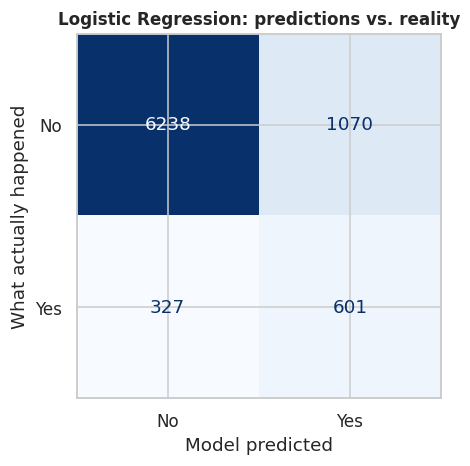

              precision    recall  f1-score   support

          No      0.950     0.854     0.899      7308
         Yes      0.360     0.648     0.462       928

    accuracy                          0.830      8236
   macro avg      0.655     0.751     0.681      8236
weighted avg      0.884     0.830     0.850      8236



In [32]:
# Confusion matrix for the chosen model: what do its mistakes actually look like?
# We pick the winner on the CROSS-VALIDATION score, so the test set stays an honest final exam.
best_name = max(cv_scores, key=cv_scores.get)
best_model = tuned_models[best_name]
print(f'Chosen model (highest cross-validation ROC-AUC): {best_name}')
print(f'Its score on the untouched test set: '
      f'{roc_auc_score(y_test, get_scores(best_model, X_test)):.4f}\n')

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, ax=ax, cmap='Blues', colorbar=False,
    display_labels=['No', 'Yes'])
ax.set_title(f'{best_name}: predictions vs. reality', fontsize=11, weight='bold')
ax.set_xlabel('Model predicted')
ax.set_ylabel('What actually happened')
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_model.predict(X_test),
                            target_names=['No', 'Yes'], digits=3))

### Interpreting the Logistic Regression coefficients

Logistic Regression gives each feature a weight. Converting that weight with `exp()` turns it
into an **odds ratio**, which reads in plain English:

- odds ratio **> 1** → this feature **raises** the chance of subscribing
- odds ratio **< 1** → this feature **lowers** it
- an odds ratio of 2.0 means "**doubles** the odds, all else equal"

Because every input was standardised or one-hot encoded, the sizes are directly comparable.

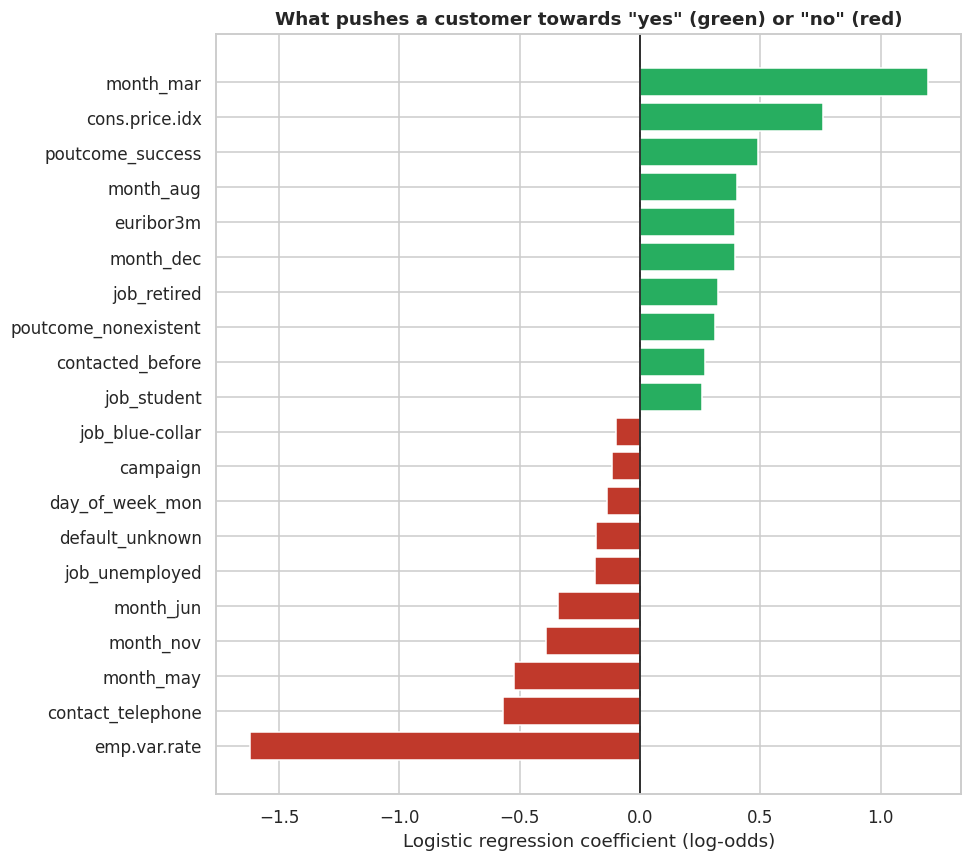

Ten strongest positive drivers (odds ratio = how many times the odds multiply):
             feature  odds_ratio
           month_mar        3.30
      cons.price.idx        2.13
    poutcome_success        1.63
           month_aug        1.50
           euribor3m        1.48
           month_dec        1.48
         job_retired        1.38
poutcome_nonexistent        1.37
    contacted_before        1.31
         job_student        1.30


In [33]:
# Pull the coefficients out of the fitted pipeline and translate them into odds ratios
lr_pipe = tuned_models['Logistic Regression']
feature_names = lr_pipe.named_steps['prep'].get_feature_names_out()
coefs = lr_pipe.named_steps['model'].coef_[0]

coef_df = (pd.DataFrame({'feature': [f.split('__', 1)[1] for f in feature_names],
                         'coefficient': coefs})
             .assign(odds_ratio=lambda d: np.exp(d['coefficient']).round(2))
             .sort_values('coefficient'))

# Show the 10 strongest positives and the 10 strongest negatives
top_effects = pd.concat([coef_df.tail(10), coef_df.head(10)]).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#C0392B' if c < 0 else '#27AE60' for c in top_effects['coefficient']]
ax.barh(top_effects['feature'], top_effects['coefficient'], color=colors)
ax.axvline(0, color='black', lw=1)
ax.set_title('What pushes a customer towards "yes" (green) or "no" (red)',
             fontsize=12, weight='bold')
ax.set_xlabel('Logistic regression coefficient (log-odds)')
plt.tight_layout()
plt.show()

print('Ten strongest positive drivers (odds ratio = how many times the odds multiply):')
print(coef_df.tail(10).sort_values('coefficient', ascending=False)
      [['feature', 'odds_ratio']].to_string(index=False))

**Reading the coefficients**

- **`emp.var.rate` is by far the strongest single effect (odds ratio 0.20).** A one-standard-
  deviation rise in the employment variation rate cuts the odds of subscribing to **one fifth**.
  Economic conditions dominate everything the bank knows about the individual customer.
- **`month_mar` (3.30)** is the strongest positive: March calls have more than three times the
  odds of the reference month, even after adjusting for the economy. **`month_may` (0.59)** and
  **`month_nov` (0.68)** drag the odds down.
- **`poutcome_success` (1.63)** confirms what the EDA showed: previous acceptors accept again.
- **`contact_telephone` (0.57)** — a landline call has barely half the odds of a mobile call.
- **`campaign` (0.89)** — every extra call to the same person shaves the odds down further.
- **`job_retired` (1.38)** and **`job_student` (1.30)** are positive; **`job_blue-collar` (0.90)**
  and **`job_services` (0.92)** are negative.

### A warning sign worth understanding: `euribor3m` has a *positive* coefficient

In the EDA, low Euribor rates went with **more** subscriptions. Here the coefficient says the
opposite. This is not a contradiction — it is **multicollinearity** in action. `euribor3m`,
`emp.var.rate` and `nr.employed` move almost in lockstep (correlations above 0.9), so the model
can shuffle credit between them in many equivalent ways. Once `emp.var.rate` has absorbed the
main economic signal, whatever is left for `euribor3m` is a small statistical correction, not a
real-world relationship.

**The practical lesson:** with correlated inputs, read the economic indicators as **one combined
block** ("a weak economy strongly favours term deposits"), never as independent levers. The
model's *predictions* are unaffected; only the individual weights are unstable.

**And a coefficient is never proof of cause.** It describes a pattern in historical data with
the other variables held fixed. It cannot tell us what would happen if the bank changed its
behaviour.

**This is the headline result.** Calling only the top-ranked **30%** of customers still reaches
about **73%** of everyone who would have subscribed. In practical terms the call centre can
**cut its calling volume by 70% while keeping roughly three-quarters of its sales** — or keep the
same staff and redirect the freed hours to higher-value work.

The **top 10%** of the list is even more striking: it contains **45%** of all subscribers, a
**4.5x lift** over calling in random order.

---
## 10. Findings

*Written for a non-technical audience. No statistics knowledge needed.*

### The bottom line
**We can predict who is worth calling, and doing so would let the bank achieve almost the same
number of sales with roughly a third of the calls.**

### Five things the data tells us

**1. The economy decides more than the customer does.**
The strongest predictors by far are interest rates and employment levels, not the customer's age
or job. When the Euribor rate is low, term deposits look attractive and people say yes. The bank
should **scale campaigns up when rates fall and scale them down when rates rise.**

**2. Past customers are the best customers.**
People who accepted a previous offer subscribe again about **65% of the time** — roughly six
times the average. This group is small, easy to identify, and is being under-used. **Build a
dedicated "previous yes" call list and work it first.**

**3. The calendar is being used backwards.**
May receives more calls than any other month yet converts poorly. March, September, October and
December convert above 40% but receive very few calls. **Rebalance the annual calling plan
towards the high-converting months.**

**4. Calling people repeatedly destroys value.**
The first call converts at 13%, the fourth or fifth at 8.7%, and the eleventh at just 3.1%.
**Cap the campaign at three attempts per customer** and spend the freed hours on fresh prospects
instead. (One customer in this dataset was called 56 times.)

**5. Mobile phones beat landlines by about three to one.**
Landline contacts convert far worse. **Prioritise customers with a mobile number on file, and
run a campaign to collect missing mobile numbers.**

### How good is the model?

| Question | Answer |
|---|---|
| Which model won? | **Logistic Regression**, on the cross-validation score. The tuned Decision Tree is effectively tied (test AUC 0.806 vs 0.801) |
| How good is it? | ROC-AUC **0.80**: given one subscriber and one non-subscriber, it scores the subscriber higher 80% of the time |
| Is that useful? | Yes. Calling the top 30% of its list reaches **73% of all subscribers**; the top 10% alone holds 45% of them |
| Does it catch subscribers? | It correctly flags **65%** of real subscribers. About 36% of the people it flags actually sign up — three times better than calling at random |
| Why not the others? | KNN scores slightly lower, the SVM scores clearly lower and takes 200x longer to train, and neither can explain its reasoning. The Decision Tree matches on score but was far more sensitive to its settings |

### The one comparison that matters
Calling everyone at random: **11 sales per 100 calls.**
Calling the model's top-ranked 10% first: **about 50 sales per 100 calls.**
